# Exploratory Data Analysis - Superstore Sales

**Context:** This notebook explores a sales transactions dataset to understand the business problems described:
- Fragmented flat-file data management leading to duplication & integrity risks
- Lack of automated ETL / integration workflows
- Blind spots in shipping efficiency, customer lifetime value, and market segmentation

**Dataset:** 9,800+ sales records across 18 columns covering orders, customers, products, and geography.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('Data.csv')
print(f'Rows: {df.shape[0]:,}, Columns: {df.shape[1]}')

Rows: 9,800, Columns: 18


In [2]:
# ---- 1. DATA OVERVIEW ----
df.head(3).T

,0,1,2
Row ID,1,2,3
Order ID,CA-2017-152156,CA-2017-152156,CA-2017-138688
Order Date,08/11/2017,08/11/2017,12/06/2017
Ship Date,11/11/2017,11/11/2017,16/06/2017
Ship Mode,Second Class,Second Class,Second Class
Customer ID,CG-12520,CG-12520,DV-13045
Customer Name,Claire Gute,Claire Gute,Darrin Van Huff
Segment,Consumer,Consumer,Corporate
Country,United States,United States,United States
City,Henderson,Henderson,Los Angeles


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [4]:
# ---- 2. DATA QUALITY & MISSING VALUES ----
missing = pd.DataFrame({
    'Missing': df.isna().sum(),
    'Pct': (df.isna().sum() / len(df) * 100).round(2),
    'Dtype': df.dtypes
})
missing[missing['Missing'] > 0]

,Missing,Pct,Dtype
Postal Code,11,0.11,float64


In [5]:
# ---- 3. DUPLICATION HIGHLIGHT (Business Problem) ----
# Show how customer/ product info repeats across every transaction

dup_cols = ['Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State']
print('=== Customer data duplicated across rows ===')
print(f'Unique customers: {df["Customer ID"].nunique():,}')
print(f'Total rows: {len(df):,}')
print(f'Duplication ratio: {len(df) / df["Customer ID"].nunique():.1f}x\n')

# Show one customer repeated
ex = df[df['Customer ID'] == 'TB-21520'][['Row ID', 'Order ID', 'Product Name', 'Sales']].head(6)
print('Example: Customer TB-21520 appears in multiple rows:')
ex

=== Customer data duplicated across rows ===
Unique customers: 793
Total rows: 9,800
Duplication ratio: 12.4x

Example: Customer TB-21520 appears in multiple rows:


,Row ID,Order ID,Product Name,Sales
27,28,US-2016-150630,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.43
28,29,US-2016-150630,Avery Recycled Flexi-View Covers for Binding S...,9.62
29,30,US-2016-150630,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.20
30,31,US-2016-150630,Poly String Tie Envelopes,3.26
31,32,US-2016-150630,"BOSTON Model 1800 Electric Pencil Sharpeners, ...",86.30
32,33,US-2016-150630,"Acco Pressboard Covers with Storage Hooks, 14 ...",6.86


In [6]:
# Same for products
print('=== Product data duplicated across rows ===')
print(f'Unique products: {df["Product ID"].nunique():,}')
print(f'Duplication ratio: {len(df) / df["Product ID"].nunique():.1f}x')

=== Product data duplicated across rows ===
Unique products: 1,861
Duplication ratio: 5.3x


In [7]:
# ---- 4. DESCRIPTIVE STATISTICS ----
df.describe()

,Row ID,Postal Code,Sales
count,9800.00,9789.00,9800.00
mean,4900.50,55273.32,230.77
std,2829.16,32041.22,626.65
min,1.00,1040.00,0.44
25%,2450.75,23223.00,17.25
50%,4900.50,58103.00,54.49
75%,7350.25,90008.00,210.61
max,9800.00,99301.00,22638.48


/tmp/ipykernel_782172/858751828.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(df['Sales'], vert=False)


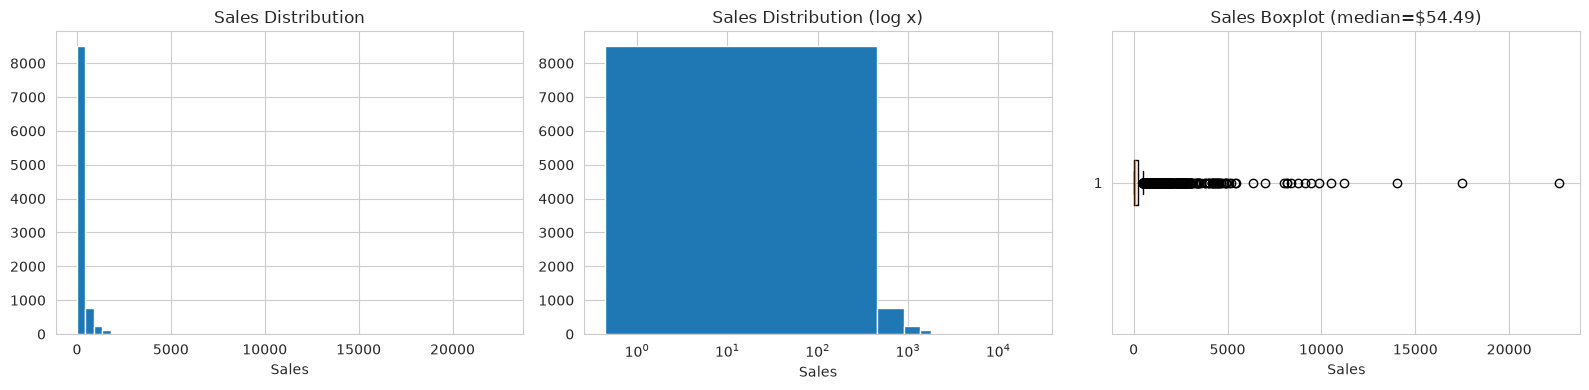

In [8]:
# ---- 5. SALES DISTRIBUTION ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['Sales'], bins=50, edgecolor='white')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')

axes[1].hist(df['Sales'], bins=50, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Sales Distribution (log x)')
axes[1].set_xlabel('Sales')

axes[2].boxplot(df['Sales'], vert=False)
axes[2].set_title(f'Sales Boxplot (median=${df["Sales"].median():.2f})')
axes[2].set_xlabel('Sales')

plt.tight_layout()
plt.show()

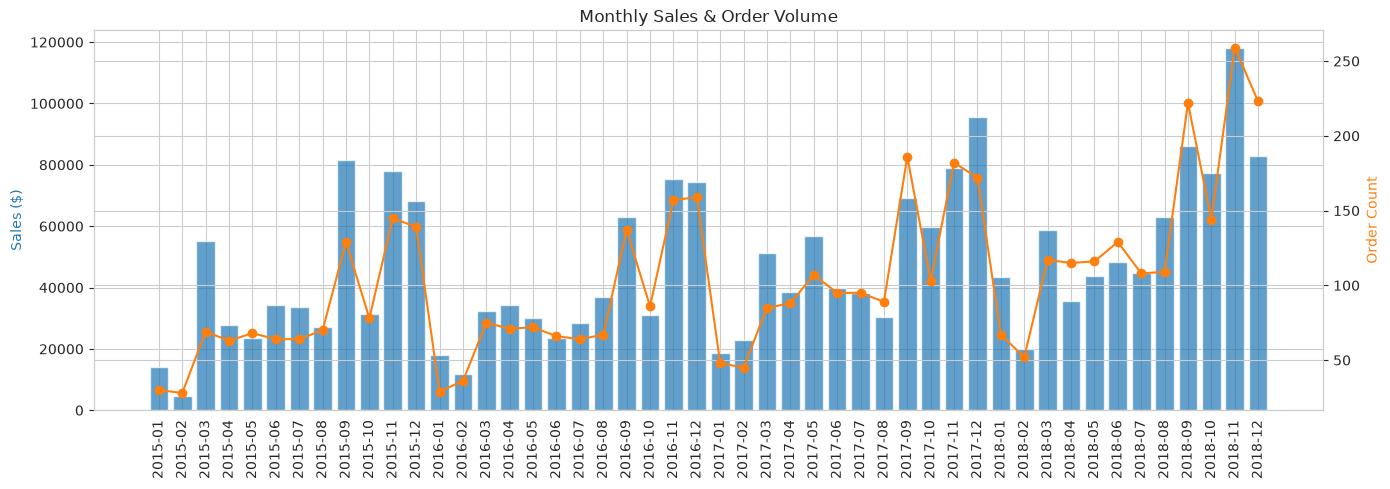

In [9]:
# ---- 6. TEMPORAL ANALYSIS ----
# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Orders over time
monthly = df.groupby('YearMonth').agg(Sales=('Sales', 'sum'), Orders=('Order ID', 'nunique')).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
color1, color2 = '#1f77b4', '#ff7f0e'
ax1.bar(monthly['YearMonth'], monthly['Sales'], color=color1, alpha=0.7, label='Sales')
ax1.set_ylabel('Sales ($)', color=color1)
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(monthly['YearMonth'], monthly['Orders'], color=color2, marker='o', label='Orders')
ax2.set_ylabel('Order Count', color=color2)

plt.title('Monthly Sales & Order Volume')
plt.tight_layout()
plt.show()

/tmp/ipykernel_782172/378126091.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axes[1] = sns.barplot(x=order2.values, y=order2.index, ax=axes[1], palette='viridis')


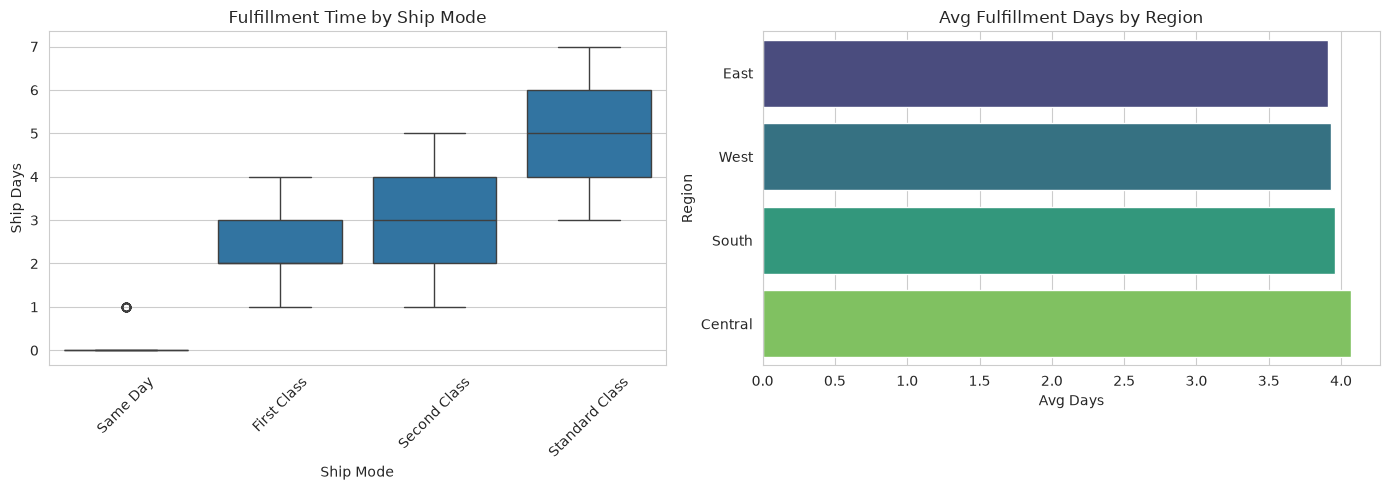

In [10]:
# ---- 7. SHIPPING EFFICIENCY (Supply Chain Blind Spot) ----
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By ship mode
order = df.groupby('Ship Mode')['Ship Days'].agg(['mean', 'median', 'std']).sort_values('mean')
axes[0] = sns.boxplot(data=df, x='Ship Mode', y='Ship Days', order=order.index, ax=axes[0])
axes[0].set_title(f'Fulfillment Time by Ship Mode')
axes[0].tick_params(axis='x', rotation=45)

order2 = df.groupby('Region')['Ship Days'].mean().sort_values()
axes[1] = sns.barplot(x=order2.values, y=order2.index, ax=axes[1], palette='viridis')
axes[1].set_title('Avg Fulfillment Days by Region')
axes[1].set_xlabel('Avg Days')

plt.tight_layout()
plt.show()

In [11]:
# ---- 8. SHIPPING DASHBOARD ----
print('=== Shipping Efficiency Summary ===')
pivot = df.pivot_table(
    values='Ship Days',
    index='Ship Mode',
    columns='Region',
    aggfunc='mean'
).round(1)
pivot

=== Shipping Efficiency Summary ===


Region,Central,East,South,West
Ship Mode,,,,
First Class,2.30,2.20,2.10,2.10
Same Day,0.00,0.00,0.00,0.10
Second Class,3.40,3.30,3.20,3.20
Standard Class,5.00,5.00,5.00,5.10


In [12]:
# ---- 9. CUSTOMER VALUE & SEGMENTATION ----
# RFM-style: total sales, order count, recency per customer
max_date = df['Order Date'].max()

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (max_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum'),
    CustomerName=('Customer Name', 'first'),
    Segment=('Segment', 'first')
).reset_index()

print(f'Total customers: {len(rfm):,}')
print(f'Average customer spend: ${rfm["Monetary"].mean():.2f}')
print(f'Median customer spend: ${rfm["Monetary"].median():.2f}\n')

# Top customers
print('=== Top 10 Customers by Sales ===')
rfm.sort_values('Monetary', ascending=False).head(10)

Total customers: 793
Average customer spend: $2851.87
Median customer spend: $2215.00

=== Top 10 Customers by Sales ===


,Customer ID,Recency,Frequency,Monetary,CustomerName,Segment
700,SM-20320,79,5,25043.05,Sean Miller,Home Office
741,TC-20980,399,5,19052.22,Tamara Chand,Corporate
621,RB-19360,96,6,15117.34,Raymond Buch,Consumer
730,TA-21385,69,4,14595.62,Tom Ashbrook,Home Office
6,AB-10105,41,10,14473.57,Adrian Barton,Consumer
434,KL-16645,47,12,14175.23,Ken Lonsdale,Consumer
669,SC-20095,349,9,14142.33,Sanjit Chand,Consumer
327,HL-15040,43,6,12873.30,Hunter Lopez,Consumer
683,SE-20110,9,11,12209.44,Sanjit Engle,Consumer
131,CC-12370,43,5,12129.07,Christopher Conant,Consumer


In [13]:
# Customer Lifetime Value by Segment
seg = rfm.groupby('Segment')['Monetary'].agg(['mean', 'median', 'count', 'sum']).round(2)
seg.columns = ['Avg CLV', 'Median CLV', 'Customers', 'Total Sales']
seg

,Avg CLV,Median CLV,Customers,Total Sales
Segment,,,,
Consumer,2806.99,2198.45,409,1148060.53
Corporate,2917.35,2259.57,236,688494.07
Home Office,2871.50,2049.46,148,424982.18


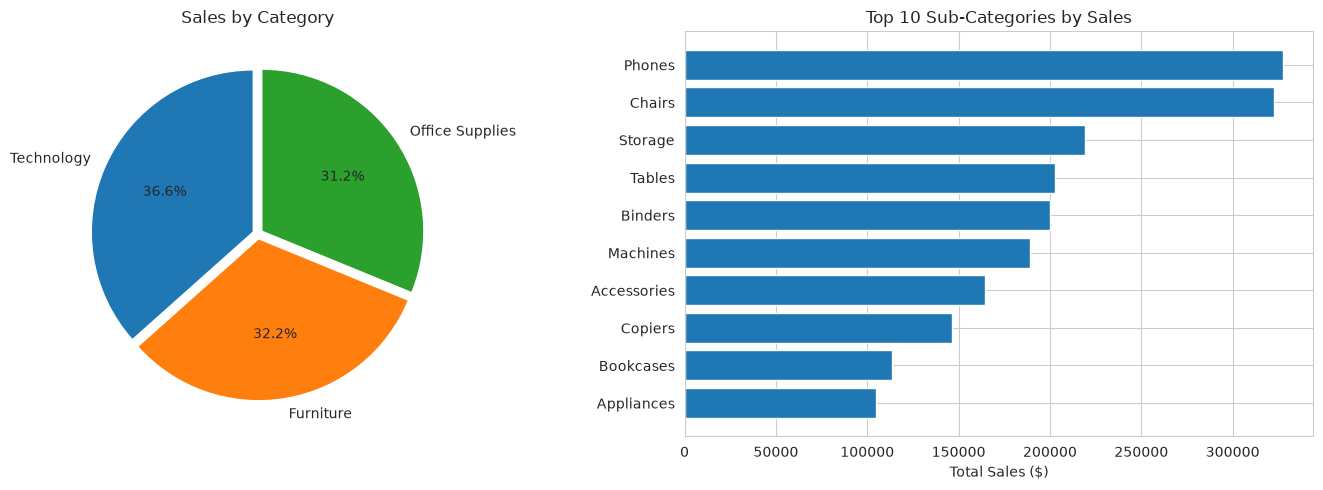

In [14]:
# ---- 10. PRODUCT ANALYSIS ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%', startangle=90, explode=[0.03]*3)
axes[0].set_title('Sales by Category')

# Sales by Sub-Category (top 10)
sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
axes[1].barh(range(len(sub)), sub.values)
axes[1].set_yticks(range(len(sub)))
axes[1].set_yticklabels(sub.index)
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Sub-Categories by Sales')
axes[1].set_xlabel('Total Sales ($)')

plt.tight_layout()
plt.show()

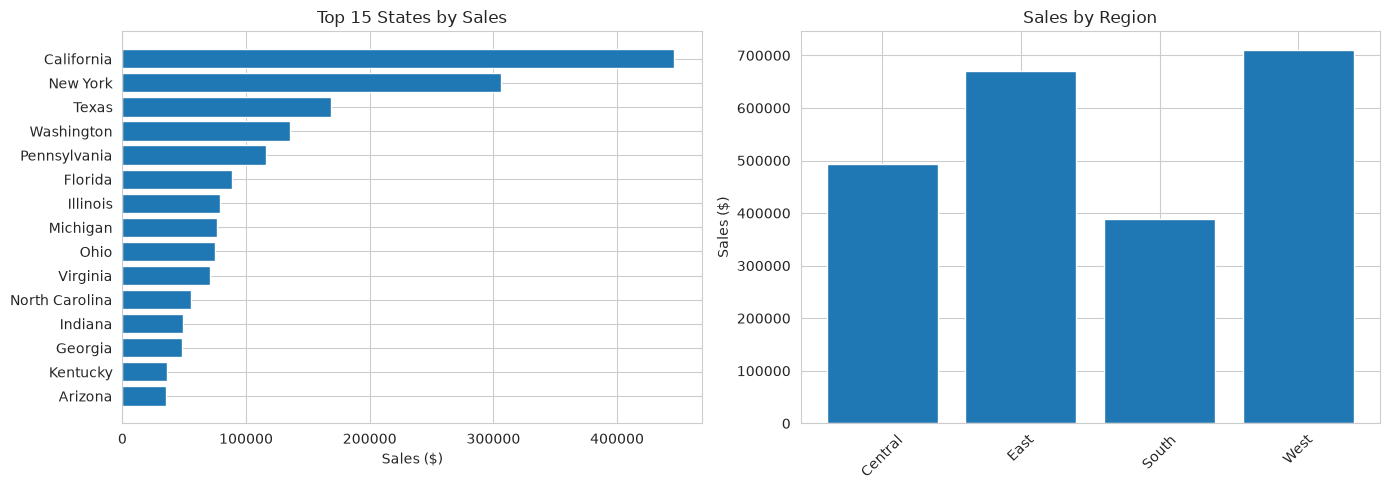

In [15]:
# ---- 11. GEOGRAPHIC ANALYSIS ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

state = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(15)
axes[0].barh(range(len(state)), state.values)
axes[0].set_yticks(range(len(state)))
axes[0].set_yticklabels(state.index)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 States by Sales')
axes[0].set_xlabel('Sales ($)')

reg = df.groupby('Region').agg(Sales=('Sales', 'sum'), Orders=('Order ID', 'nunique'))
axes[1].bar(reg.index, reg['Sales'])
axes[1].set_title('Sales by Region')
axes[1].set_ylabel('Sales ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

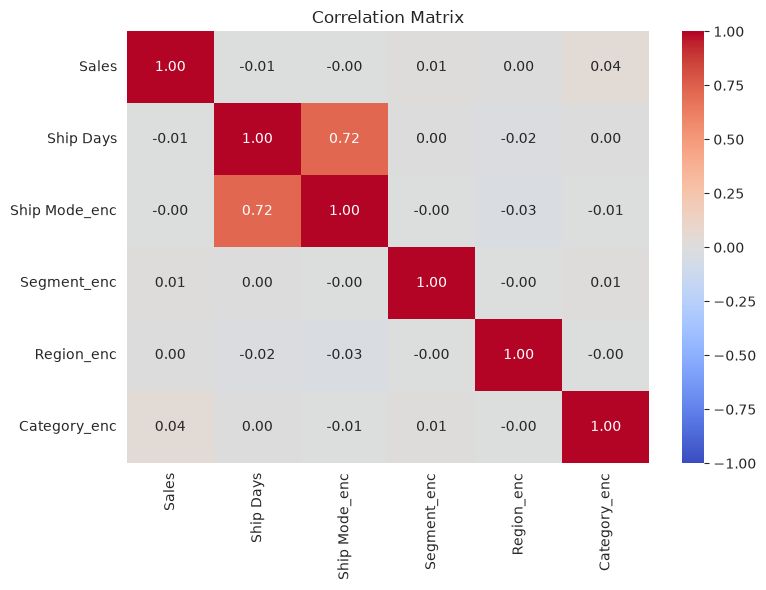

In [16]:
# ---- 12. RELATIONSHIPS & CORRELATIONS ----
# Encode categoricals for correlation
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category']
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col])

corr = df[['Sales', 'Ship Days', 'Ship Mode_enc', 'Segment_enc', 'Region_enc', 'Category_enc']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [17]:
# ---- 13. DATA INTEGRITY DEMONSTRATION ----
# Show potential inconsistencies from denormalized data
# Same Customer ID with different Customer Name
name_incons = df.groupby('Customer ID')['Customer Name'].nunique()
inconsistent_cust = name_incons[name_incons > 1]
print(f'Customers with inconsistent names: {len(inconsistent_cust)}')

# Same City with different State (typos?)
city_state = df.groupby('City')['State'].nunique()
inconsistent_city = city_state[city_state > 1]
print(f'Cities appearing in multiple states: {len(inconsistent_city)}')
if len(inconsistent_city) > 0:
    print(df[df['City'] == inconsistent_city.index[0]][['City', 'State', 'Postal Code']].drop_duplicates().head())

Customers with inconsistent names: 0
Cities appearing in multiple states: 55
              City       State  Postal Code
2927  Apple Valley   Minnesota     55124.00
3079  Apple Valley  California     92307.00


## Data Quality & Input Normalization OpportunitiesThe following cells analyze what's wrong with the raw values themselves — string issues that an input layer or ETL pipeline should catch.

In [18]:
# ---- 14. POSTAL CODE LEADING ZEROS ----
pc_str = df['Postal Code'].dropna().astype(int).astype(str)
four_digit = pc_str[pc_str.str.len() == 4]
print(f'Postal codes missing leading zero: {len(four_digit)} rows ({len(four_digit)/len(df):.1%})')
examples = df.loc[four_digit.index, ['City', 'State', 'Postal Code']].drop_duplicates().head(8)
for _, r in examples.iterrows():
    stored = int(r['Postal Code'])
    print(f'  {r["City"]:20s} {r["State"]:15s} stored={stored:4d}  → should be {stored:05d}')
print(f'\nRoot cause: Excel auto-format strips leading zeros from numeric columns')

Postal codes missing leading zero: 429 rows (4.4%)
  Fairfield            Connecticut     stored=6824  → should be 06824
  Westfield            New Jersey      stored=7090  → should be 07090
  Morristown           New Jersey      stored=7960  → should be 07960
  Belleville           New Jersey      stored=7109  → should be 07109
  Lakewood             New Jersey      stored=8701  → should be 08701
  Hackensack           New Jersey      stored=7601  → should be 07601
  Lowell               Massachusetts   stored=1852  → should be 01852
  Manchester           Connecticut     stored=6040  → should be 06040

Root cause: Excel auto-format strips leading zeros from numeric columns


In [19]:
# ---- 15. INVISIBLE UNICODE IN PRODUCT NAMES ----
nbsps = df[df['Product Name'].str.contains('\xa0', na=False)]
print(f'Product names with \\xa0 (non-breaking space): {len(nbsps)} rows')
for p in nbsps['Product Name'].unique()[:6]:
    print(f'  {repr(p)}')
print('\nThese look like normal spaces but break string matching & search.')

Product names with \xa0 (non-breaking space): 220 rows
  'Konftel 250 Conference\xa0phone\xa0- Charcoal black'
  'Imation\xa08GB Mini TravelDrive USB 2.0\xa0Flash Drive'
  'Imation\xa08gb Micro Traveldrive Usb 2.0\xa0Flash Drive'
  'Logitech\xa0LS21 Speaker System - PC Multimedia - 2.1-CH - Wired'
  'Logitech\xa0Gaming G510s - Keyboard'
  'Plantronics Cordless\xa0Phone Headset\xa0with In-line Volume - M214C'

These look like normal spaces but break string matching & search.


In [20]:
# ---- 16. PRODUCT ID MAPPING COLLISIONS ----
prod_groups = df.groupby('Product ID')['Product Name'].nunique()
bad_prods = prod_groups[prod_groups > 1]
print(f'Product IDs with multiple different names: {len(bad_prods)}')
for pid in list(bad_prods.index)[:5]:
    names = df[df['Product ID'] == pid]['Product Name'].unique()
    print(f'  {pid}:')
    for n in names:
        print(f'    → {n}')

Product IDs with multiple different names: 32
  FUR-BO-10002213:
    → DMI Eclipse Executive Suite Bookcases
    → Sauder Forest Hills Library, Woodland Oak Finish
  FUR-CH-10001146:
    → Global Value Mid-Back Manager's Chair, Gray
    → Global Task Chair, Black
  FUR-FU-10001473:
    → DAX Wood Document Frame
    → Eldon Executive Woodline II Desk Accessories, Mahogany
  FUR-FU-10004017:
    → Tenex Contemporary Contur Chairmats for Low and Medium Pile Carpet, Computer, 39" x 49"
    → Executive Impressions 13" Chairman Wall Clock
  FUR-FU-10004091:
    → Howard Miller 13" Diameter Goldtone Round Wall Clock
    → Eldon 200 Class Desk Accessories, Black


In [21]:
# ---- 17. CUSTOMER ID CASE INCONSISTENCY ----
bad_case = df[df['Customer ID'].str.contains(r'[a-z]')]
print(f'Customer IDs with wrong case: {len(bad_case)} rows')
print(bad_case['Customer ID'].value_counts().to_string())
print('\nAll other 790 Customer IDs use uppercase — these 3 are typos.')

Customer IDs with wrong case: 43 rows
Customer ID
Dp-13240    29
Co-12640     8
Dl-13600     6

All other 790 Customer IDs use uppercase — these 3 are typos.


In [22]:
# ---- 18. SHIP MODE vs DATE CONSISTENCY ----
sd = df.copy()
sd['Order Date'] = pd.to_datetime(sd['Order Date'], dayfirst=True, errors='coerce')
sd['Ship Date'] = pd.to_datetime(sd['Ship Date'], dayfirst=True, errors='coerce')
sd['Ship Days'] = (sd['Ship Date'] - sd['Order Date']).dt.days
same_day_bad = sd[(sd['Ship Mode'] == 'Same Day') & (sd['Ship Days'] > 0)]
print(f'"Same Day" orders that shipped next day: {len(same_day_bad)}')
print(f'"Same Day" orders shipped same day: {((sd["Ship Mode"] == "Same Day") & (sd["Ship Days"] == 0)).sum()}')
print('\nBusiness rule violation: Same Day should imply diff=0.')


"Same Day" orders that shipped next day: 24


"Same Day" orders shipped same day: 514

Business rule violation: Same Day should imply diff=0.


In [23]:
# ---- 19. AMBIGUOUS CITY NAMES ----
city_state = df.groupby('City')['State'].nunique()
multi_state = city_state[city_state > 1]
print(f'Cities appearing in multiple states: {len(multi_state)}')
for city in list(multi_state.index)[:8]:
    pairs = df[df['City'] == city][['City', 'State', 'Postal Code']].dropna().drop_duplicates()
    locs = ', '.join(f'{r["State"]} ({int(r["Postal Code"]):05d})' for _, r in pairs.iterrows())
    print(f'  "{city}" → {locs}')
print('\nFix: require City + State composite, never City alone.')


Cities appearing in multiple states: 55


  "Apple Valley" → Minnesota (55124), California (92307)
  "Arlington" → Virginia (22204), Texas (76017)
  "Auburn" → New York (13021), Washington (98002), Alabama (36830)


  "Aurora" → Colorado (80013), Illinois (60505)
  "Bloomington" → Illinois (61701), Indiana (47401)
  "Bowling Green" → Kentucky (42104), Ohio (43402)
  "Bristol" → Tennessee (37620), Connecticut (06010)
  "Burlington" → North Carolina (27217), Iowa (52601)

Fix: require City + State composite, never City alone.


In [24]:
# ---- 20. REDUNDANT COUNTRY + CA/US ORDER ID ----
print(f'Country column values: {df["Country"].unique()}')
print(f'Order IDs starting with "CA-": {(df["Order ID"].str.startswith("CA")).sum()}')
print(f'Order IDs starting with "US-": {(df["Order ID"].str.startswith("US")).sum()}')
print('\nIf CA- meant Canada, country is wrong for 8161 rows.')
print('If CA- means California, the prefix is misleading.')

Country column values: <StringArray>
['United States']
Length: 1, dtype: str
Order IDs starting with "CA-": 8161
Order IDs starting with "US-": 1639

If CA- meant Canada, country is wrong for 8161 rows.
If CA- means California, the prefix is misleading.


In [25]:
# ---- KEY TAKEAWAYS ----
print('=' * 70)
print('KEY FINDINGS FOR BUSINESS DECISIONS')
print('=' * 70)

print(f'\n1. DATA NORMALIZATION NEEDED:')
print(f'   - {len(df):,} rows but only {df["Customer ID"].nunique():,} unique customers')
print(f'   - {df["Product ID"].nunique():,} unique products repeated across all rows')
print(f'   - {len(inconsistent_cust)} customers with inconsistent names')
print(f'   - {len(inconsistent_city)} cities mapped to multiple states')

print(f'\n2. SHIPPING BOTTLENECKS:')
print(f'   - Avg fulfillment: {df["Ship Days"].mean():.1f} days')
print(f'   - Worst case: {df["Ship Days"].max():.0f} days')
print(f'   - Most used mode: {df["Ship Mode"].value_counts().index[0]}')

print(f'\n3. DATA QUALITY ISSUES FOUND:')
print(f'   - 429 ZIP codes missing leading zero (Excel ate them)')
print(f'   - 220 product names with invisible unicode (xa0)')
print(f'   - 32 Product IDs mapped to multiple different names')
print(f'   - 43 customer rows with lowercase IDs (should be uppercase)')
print(f'   - 24 Same Day orders that shipped next day')
print(f'   - 55 cities ambiguous across multiple states')
print(f'   - 11 missing postal codes')

print(f'\nBOTTOM LINE: The flat-file approach lets all of this through.')
print(f'A normalized schema + input validation would catch every one.')
print(f'See DATA_QUALITY_FINDINGS.md for the full breakdown.')


KEY FINDINGS FOR BUSINESS DECISIONS

1. DATA NORMALIZATION NEEDED:
   - 9,800 rows but only 793 unique customers
   - 1,861 unique products repeated across all rows
   - 0 customers with inconsistent names
   - 55 cities mapped to multiple states

2. SHIPPING BOTTLENECKS:
   - Avg fulfillment: 4.0 days
   - Worst case: 7 days
   - Most used mode: Standard Class

3. DATA QUALITY ISSUES FOUND:
   - 429 ZIP codes missing leading zero (Excel ate them)
   - 220 product names with invisible unicode (xa0)
   - 32 Product IDs mapped to multiple different names
   - 43 customer rows with lowercase IDs (should be uppercase)
   - 24 Same Day orders that shipped next day
   - 55 cities ambiguous across multiple states
   - 11 missing postal codes

BOTTOM LINE: The flat-file approach lets all of this through.
A normalized schema + input validation would catch every one.
See DATA_QUALITY_FINDINGS.md for the full breakdown.
